In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from sklearn.cluster import KMeans
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import numpy as np
import os
import scipy
import seaborn as sns
from datetime import datetime
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.stats import shapiro
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats import gaussian_kde

In [2]:
# Charger le fichier CSV
fichier_csv= r"C:\Users\laure\OneDrive\Documents\Outils de programmation-2024\2000-2021 SINGLE TURKEY FIRE_M-C61_214067.csv"

In [3]:
# Charger les données dans un DataFrame pandas
df= pd.read_csv(fichier_csv)

C:\Users\laure\AppData\Local\Temp\ipykernel_19552\2194497386.py:2: DtypeWarning: Columns (10,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv(fichier_csv)


In [4]:
# Nettoyage de la colonne "type"
df["type"] = df["type"].astype(str).str.strip()  # Supprimer les espaces
df["type"] = df["type"].replace("", pd.NA)  # Remplacer les chaînes vides par NaN
df.columns = df.columns.str.strip() # Supprime les espaces autour des noms de colonnes

In [5]:
# Vérifier les valeurs manquantes
missing_values = df.isna().sum()

In [6]:
# Vérifier les doublons
duplicate_count = df.duplicated().sum()

In [7]:
# Afficher les 5 premières lignes pour inspecter les données
print(df.head())

   latitude  longitude  brightness  scan  track     acq_date  acq_time  \
0   36.8527    35.3594       306.0   2.1    1.4  2000-11-01        815   
1   40.5441    35.1786       307.8   1.1    1.0  2000-11-02        857   
2   40.1473    35.0444       305.3   1.1    1.0  2000-11-02        857   
3   40.5421    35.1909       310.0   1.1    1.0  2000-11-02        857   
4   41.2569    31.4172       307.9   1.1    1.0  2000-11-02        857   

    satellite   instrument  confidence version  bright_t31   frp   daynight  \
0  Terra       MODIS                60    6.03       294.4  13.2  D           
1  Terra       MODIS                66    6.03       296.0   5.8  D           
2  Terra       MODIS                46    6.03       293.5   4.3  D           
3  Terra       MODIS                69    6.03       296.1   7.3  D           
4  Terra       MODIS                 0    6.03       290.4   8.0  D           

  type  
0    0  
1    0  
2    0  
3    0  
4    2  


In [8]:
# Convertir les données en heure
def convertir_en_heure(entier):
    heure = entier // 100
    minute = entier % 100
    return f"{heure}:{minute:02d}"

df['acq_time'] = df['acq_time'].astype(int)
df['acq_time'] = df['acq_time'].apply(convertir_en_heure) 

In [9]:
# Vérifier que les données sont en heure
print(df.head())

   latitude  longitude  brightness  scan  track     acq_date acq_time  \
0   36.8527    35.3594       306.0   2.1    1.4  2000-11-01      8:15   
1   40.5441    35.1786       307.8   1.1    1.0  2000-11-02      8:57   
2   40.1473    35.0444       305.3   1.1    1.0  2000-11-02      8:57   
3   40.5421    35.1909       310.0   1.1    1.0  2000-11-02      8:57   
4   41.2569    31.4172       307.9   1.1    1.0  2000-11-02      8:57   

    satellite   instrument  confidence version  bright_t31   frp   daynight  \
0  Terra       MODIS                60    6.03       294.4  13.2  D           
1  Terra       MODIS                66    6.03       296.0   5.8  D           
2  Terra       MODIS                46    6.03       293.5   4.3  D           
3  Terra       MODIS                69    6.03       296.1   7.3  D           
4  Terra       MODIS                 0    6.03       290.4   8.0  D           

  type  
0    0  
1    0  
2    0  
3    0  
4    2  


In [10]:
# Afficher les informations générales sur le DataFrame
print("\nInformations sur les données :")
print(df.info())


Informations sur les données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211309 entries, 0 to 211308
Data columns (total 15 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   latitude    211309 non-null  float64
 1   longitude   211309 non-null  float64
 2   brightness  211309 non-null  float64
 3   scan        211309 non-null  float64
 4   track       211309 non-null  float64
 5   acq_date    211309 non-null  object 
 6   acq_time    211309 non-null  object 
 7   satellite   211309 non-null  object 
 8   instrument  211309 non-null  object 
 9   confidence  211309 non-null  int64  
 10  version     211309 non-null  object 
 11  bright_t31  211309 non-null  float64
 12  frp         211309 non-null  float64
 13  daynight    211309 non-null  object 
 14  type        205918 non-null  object 
dtypes: float64(7), int64(1), object(7)
memory usage: 24.2+ MB
None


In [11]:
# Afficher les statistiques descriptives pour les variables quantitatives
print("\nStatistiques descriptives des variables quantitatives :")
print(df.describe())


Statistiques descriptives des variables quantitatives :
            latitude      longitude     brightness           scan  \
count  211309.000000  211309.000000  211309.000000  211309.000000   
mean       38.096869      35.810523     323.103487       1.519333   
std         1.259144       4.218867      15.710290       0.735847   
min        35.822100      25.723600     300.000000       1.000000   
25%        37.113200      33.037500     311.300000       1.000000   
50%        37.711700      35.817400     322.100000       1.200000   
75%        38.931600      39.755500     331.300000       1.700000   
max        42.033000      44.796700     503.530000       4.820000   

               track     confidence     bright_t31            frp  
count  211309.000000  211309.000000  211309.000000  211309.000000  
mean        1.183241      66.453923     302.475387      30.341675  
std         0.228731      19.297827      10.168149      67.171226  
min         1.000000       0.000000     265.20000

In [12]:
# Afficher les résultats
print("Valeurs manquantes par colonne :")
print(missing_values)
print("\nNombre de doublons :", duplicate_count)
print("\nValeurs uniques dans 'type' après correction :")
print(df["type"].value_counts(dropna=False))

Valeurs manquantes par colonne :
latitude         0
longitude        0
brightness       0
scan             0
track            0
acq_date         0
acq_time         0
satellite        0
instrument       0
confidence       0
version          0
bright_t31       0
frp              0
daynight         0
type          5391
dtype: int64

Nombre de doublons : 0

Valeurs uniques dans 'type' après correction :
type
0       191670
2        14163
<NA>      5391
3           85
Name: count, dtype: int64


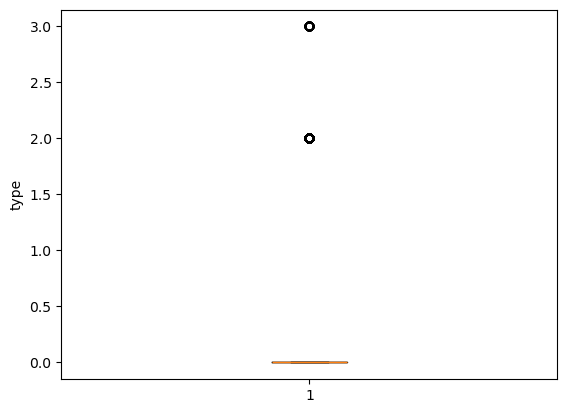

In [13]:
# Traitement des données aberrantes à l'aide d'un diagramme en boîte

# Convertir la colonne 'type' en numérique (les valeurs non convertibles seront remplacées par NaN)
df['type'] = pd.to_numeric(df['type'], errors='coerce')

# Remplacer les NaN par 0
df['type'] = df['type'].fillna(0)

# Maintenant, tu peux créer le boxplot sans problème
plt.boxplot(df['type'])
plt.ylabel('type')
plt.show()

In [14]:
# Assurez-vous que la colonne 'type' est bien numérique (comme expliqué précédemment)
df['type'] = pd.to_numeric(df['type'], errors='coerce')
df['type'] = df['type'].fillna(0)

# Calcul des quartiles
Q1 = df['type'].quantile(0.25)
Q3 = df['type'].quantile(0.75)
IQR = Q3 - Q1

# Définir les bornes pour les valeurs non aberrantes
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtrer les données pour supprimer les valeurs aberrantes
df_filtered = df[(df['type'] >= lower_bound) & (df['type'] <= upper_bound)]

# Afficher le résultat
print(f"Nombre de lignes avant le filtrage : {len(df)}")
print(f"Nombre de lignes après le filtrage : {len(df_filtered)}")

Nombre de lignes avant le filtrage : 211309
Nombre de lignes après le filtrage : 197061


In [15]:
# Filtrer les données pour chaque type de feu spécifique
df_type_0 = df[df['type'] == 0]  # Feu de végétation présumé
df_type_1 = df[df['type'] == 1]  # Volcan actif
df_type_2 = df[df['type'] == 2]  # Autres sources terrestres statiques
df_type_3 = df[df['type'] == 3]  # Détection en mer

# Affichage des résultats
print(f"Nombre de lignes pour le type 0 : {len(df_type_0)}")
print(f"Nombre de lignes pour le type 1 : {len(df_type_1)}")
print(f"Nombre de lignes pour le type 2 : {len(df_type_2)}")
print(f"Nombre de lignes pour le type 3 : {len(df_type_3)}")

Nombre de lignes pour le type 0 : 197061
Nombre de lignes pour le type 1 : 0
Nombre de lignes pour le type 2 : 14163
Nombre de lignes pour le type 3 : 85


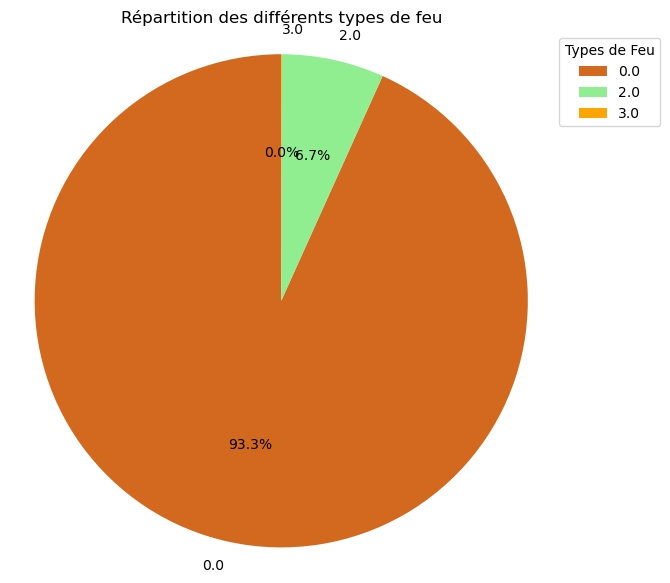

In [16]:
# Création d'un graphique en camembert

# Compter les occurrences de chaque type de feu
type_counts = df['type'].value_counts()

# Créer un graphique en camembert
plt.figure(figsize=(7, 7))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90, colors=['chocolate', 'lightgreen', 'orange', 'plum'])
plt.title('Répartition des différents types de feu')
plt.axis('equal')  # Pour avoir un cercle parfait

# Ajouter une légende
plt.legend(type_counts.index, title="Types de Feu", loc="upper left", bbox_to_anchor=(1, 1))

# Afficher le graphique
plt.show()

In [26]:
# Convertir la colonne date en format datetime
df["acq_date"] = pd.to_datetime(df["acq_date"])

In [27]:
# Extraire l'année
df["year"] = df["acq_date"].dt.year

In [28]:
# Définir les années disponibles
years = sorted(df["year"].unique())

In [29]:
# Vérifier si la colonne 'brightness' existe
if 'brightness' in df.columns:
    # Définir le nombre de catégories
    num_categories = 4

    # Calculer les limites des catégories
    frp_min = df['brightness'].min()
    frp_max = df['brightness'].max()
    category_ranges = np.linspace(frp_min, frp_max, num_categories + 1)

    # Créer les catégories
    categories = [f'Zone {i + 1}' for i in range(num_categories)]

    # Assigner une catégorie à chaque point
    df['brightness_category'] = pd.cut(df['brightness'], bins=category_ranges, labels=categories, include_lowest=True)

    print("Colonne 'brightness_category' créée avec succès.")
else:
    print("Erreur : La colonne 'brightness' n'existe pas dans le DataFrame.")

Colonne 'brightness_category' créée avec succès.


In [30]:
# Calcul des limites des catégories
frp_min = df['brightness'].min()
frp_max = df['brightness'].max()
category_ranges = np.linspace(frp_min, frp_max, num_categories + 1)
print(df[['latitude', 'longitude', 'brightness']].describe())

            latitude      longitude     brightness
count  211309.000000  211309.000000  211309.000000
mean       38.096869      35.810523     323.103487
std         1.259144       4.218867      15.710290
min        35.822100      25.723600     300.000000
25%        37.113200      33.037500     311.300000
50%        37.711700      35.817400     322.100000
75%        38.931600      39.755500     331.300000
max        42.033000      44.796700     503.530000


In [31]:
# Vérifier si la colonne 'brightness' existe
if 'brightness' in df.columns:
    # Définir le nombre de catégories pour l'intensité des incendies
    num_categories = 4

    # Calculer les limites des catégories
    frp_min = df['brightness'].min()
    frp_max = df['brightness'].max()
    category_ranges = np.linspace(frp_min, frp_max, num_categories + 1)

    # Créer les catégories
    categories = [f'Zone {i + 1}' for i in range(num_categories)]

    # Assigner une catégorie à chaque point
    df['brightness_category'] = pd.cut(df['brightness'], bins=category_ranges, labels=categories, include_lowest=True)

    print("Colonne 'brightness_category' créée avec succès.")
else:
    print("Erreur : La colonne 'brightness' n'existe pas dans le DataFrame.")

Colonne 'brightness_category' créée avec succès.


In [32]:
# Vérification des données dans les catégories
for category in categories:
    print(f"Nombre de points pour {category} : {len(df[df['brightness_category'] == category])}")

Nombre de points pour Zone 1 : 201915
Nombre de points pour Zone 2 : 8838
Nombre de points pour Zone 3 : 504
Nombre de points pour Zone 4 : 52


In [33]:
# Vérification des données de latitude et longitude
print("Latitude min/max :", df['latitude'].min(), df['latitude'].max())
print("Longitude min/max :", df['longitude'].min(), df['longitude'].max())
print("Brightness min/max :", df['brightness'].min(), df['brightness'].max())

Latitude min/max : 35.8221 42.033
Longitude min/max : 25.7236 44.7967
Brightness min/max : 300.0 503.53


In [37]:
# Vérifier qu'il y a bien des incendies
for year in range(2000, 2022):  # Boucle sur les années
    df_year = df[df['year'] == year]  # Filtrer les données de l'année
    print(f"Année {year}: {len(df_year)} incendies détectés")  # Afficher le nombre d'incendies

Année 2000: 496 incendies détectés
Année 2001: 5162 incendies détectés
Année 2002: 6886 incendies détectés
Année 2003: 7733 incendies détectés
Année 2004: 7901 incendies détectés
Année 2005: 8303 incendies détectés
Année 2006: 9459 incendies détectés
Année 2007: 8791 incendies détectés
Année 2008: 6164 incendies détectés
Année 2009: 19979 incendies détectés
Année 2010: 13653 incendies détectés
Année 2011: 18465 incendies détectés
Année 2012: 7115 incendies détectés
Année 2013: 11521 incendies détectés
Année 2014: 6825 incendies détectés
Année 2015: 18089 incendies détectés
Année 2016: 13591 incendies détectés
Année 2017: 9596 incendies détectés
Année 2018: 8087 incendies détectés
Année 2019: 8347 incendies détectés
Année 2020: 8834 incendies détectés
Année 2021: 6312 incendies détectés


In [38]:
df['year'] = df['year'].astype(int)  # Assurez-vous que les années sont bien en format entier

In [39]:
print(f"Catégories présentes pour {year}:", df_year['brightness_category'].unique())

Catégories présentes pour 2021: ['Zone 1', 'Zone 2', 'Zone 3', 'Zone 4']
Categories (4, object): ['Zone 1' < 'Zone 2' < 'Zone 3' < 'Zone 4']


In [40]:
print(df['brightness_category'].unique())  # Liste des valeurs réelles

['Zone 1', 'Zone 2', 'Zone 3', 'Zone 4']
Categories (4, object): ['Zone 1' < 'Zone 2' < 'Zone 3' < 'Zone 4']


In [41]:
print(df_year[['latitude', 'longitude']].describe())

          latitude    longitude
count  6312.000000  6312.000000
mean     37.486744    33.419367
std       1.087504     4.600995
min      35.881550    26.145100
25%      36.889855    29.131835
50%      37.068445    31.905985
75%      37.583045    37.562250
max      41.973400    44.717500


Année 2000: 496 incendies détectés
Catégories présentes pour 2000: ['Faible', 'Moyenne']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']
⚠️ Aucune donnée pour Forte en 2000
⚠️ Aucune donnée pour Très Forte en 2000


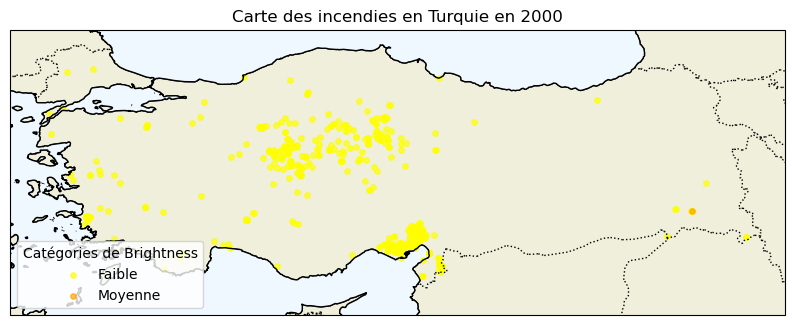

Année 2001: 5162 incendies détectés
Catégories présentes pour 2001: ['Faible', 'Moyenne', 'Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']
⚠️ Aucune donnée pour Très Forte en 2001


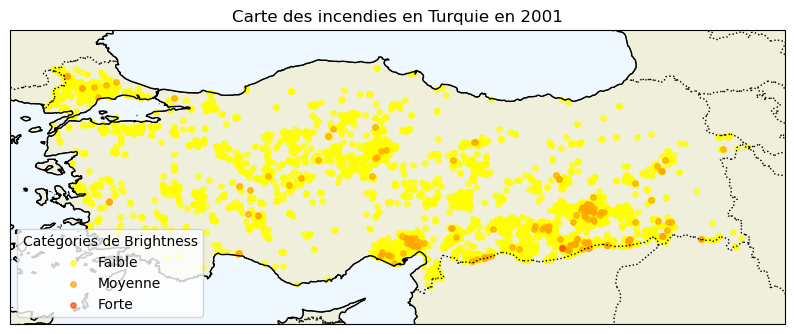

Année 2002: 6886 incendies détectés
Catégories présentes pour 2002: ['Faible', 'Moyenne', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


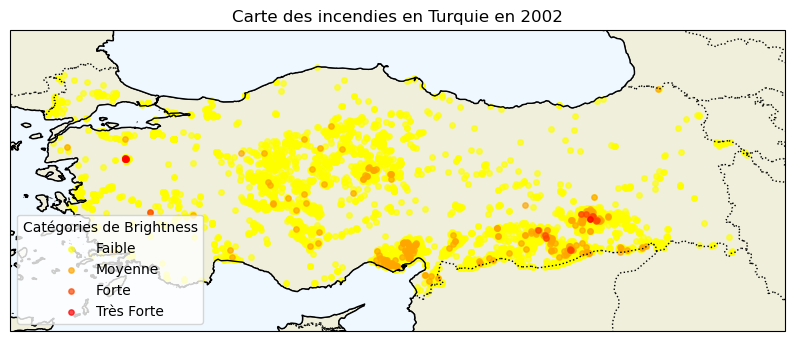

Année 2003: 7733 incendies détectés
Catégories présentes pour 2003: ['Faible', 'Moyenne', 'Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']
⚠️ Aucune donnée pour Très Forte en 2003


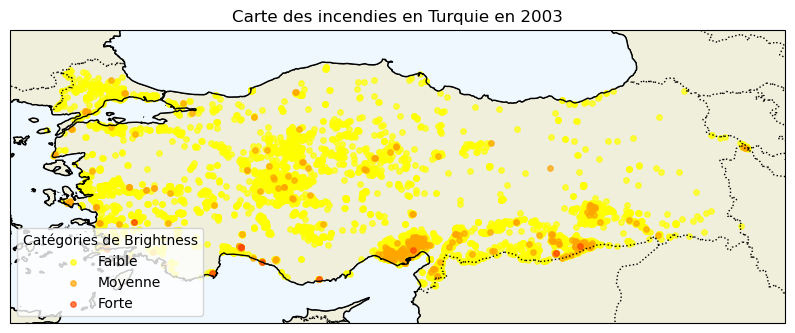

Année 2004: 7901 incendies détectés
Catégories présentes pour 2004: ['Faible', 'Moyenne', 'Très Forte', 'Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


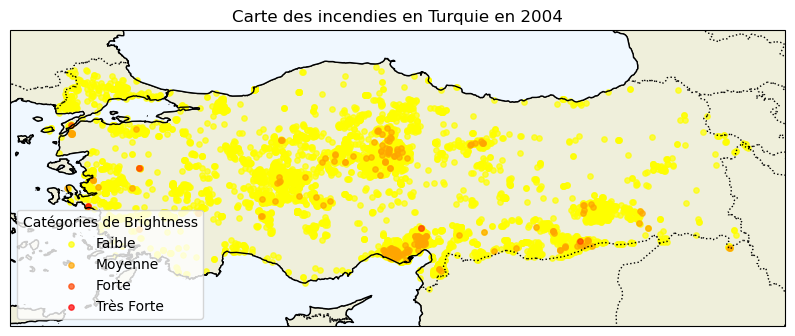

Année 2005: 8303 incendies détectés
Catégories présentes pour 2005: ['Faible', 'Moyenne', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


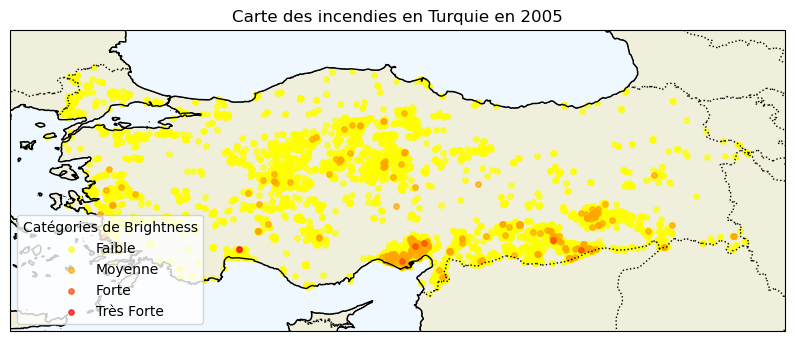

Année 2006: 9459 incendies détectés
Catégories présentes pour 2006: ['Faible', 'Moyenne', 'Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']
⚠️ Aucune donnée pour Très Forte en 2006


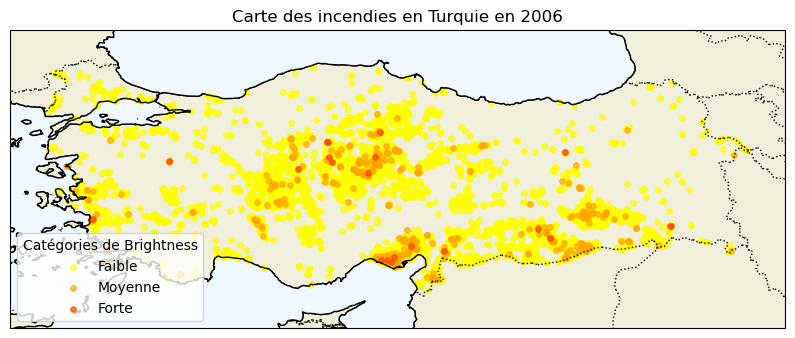

Année 2007: 8791 incendies détectés
Catégories présentes pour 2007: ['Faible', 'Moyenne', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


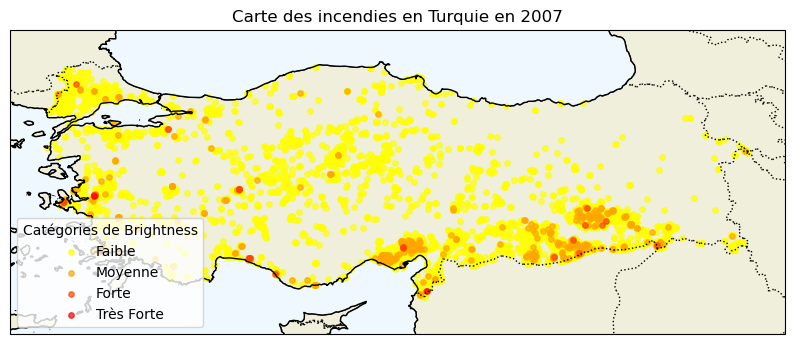

Année 2008: 6164 incendies détectés
Catégories présentes pour 2008: ['Faible', 'Moyenne', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


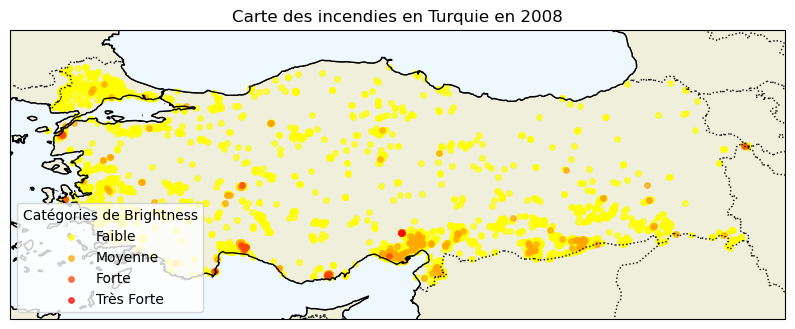

Année 2009: 19979 incendies détectés
Catégories présentes pour 2009: ['Faible', 'Moyenne', 'Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']
⚠️ Aucune donnée pour Très Forte en 2009


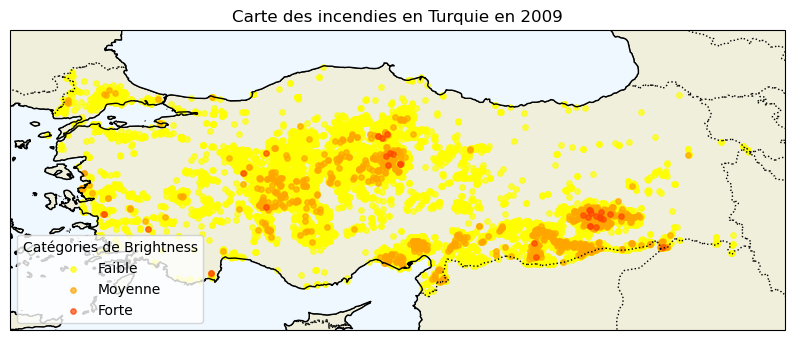

Année 2010: 13653 incendies détectés
Catégories présentes pour 2010: ['Faible', 'Moyenne', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


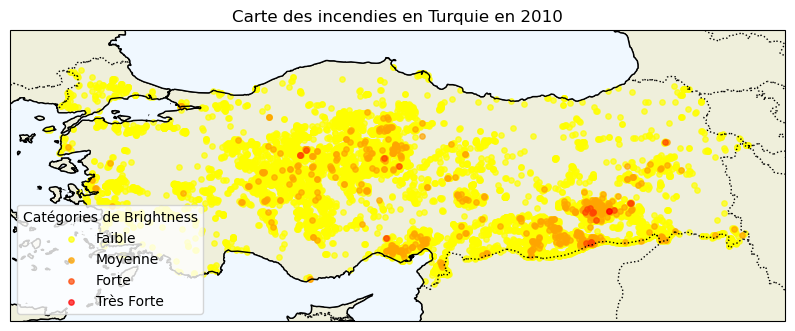

Année 2011: 18465 incendies détectés
Catégories présentes pour 2011: ['Faible', 'Moyenne', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


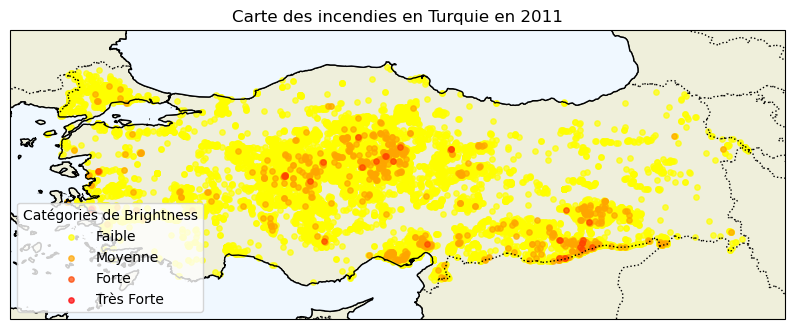

Année 2012: 7115 incendies détectés
Catégories présentes pour 2012: ['Faible', 'Moyenne', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


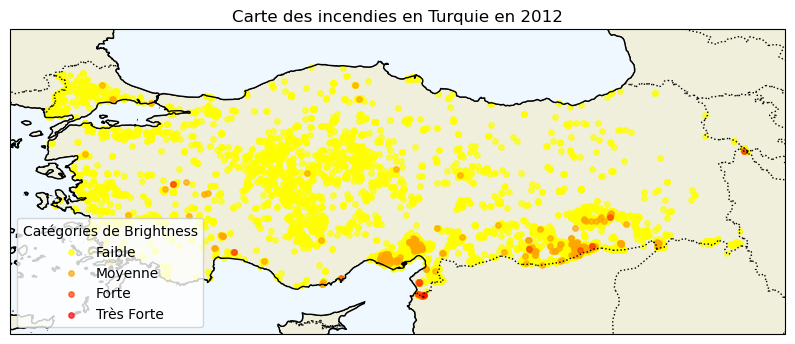

Année 2013: 11521 incendies détectés
Catégories présentes pour 2013: ['Faible', 'Moyenne', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


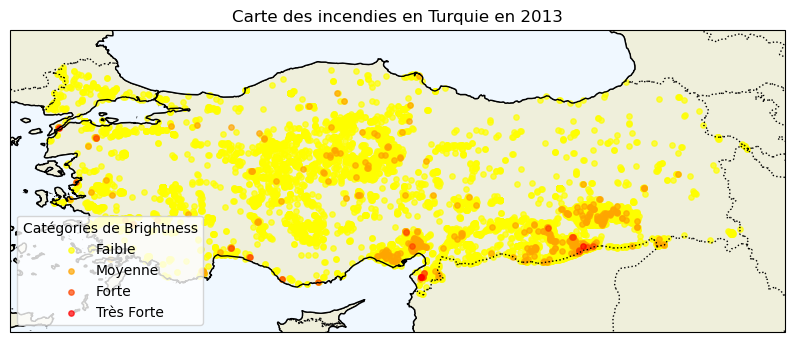

Année 2014: 6825 incendies détectés
Catégories présentes pour 2014: ['Faible', 'Moyenne', 'Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']
⚠️ Aucune donnée pour Très Forte en 2014


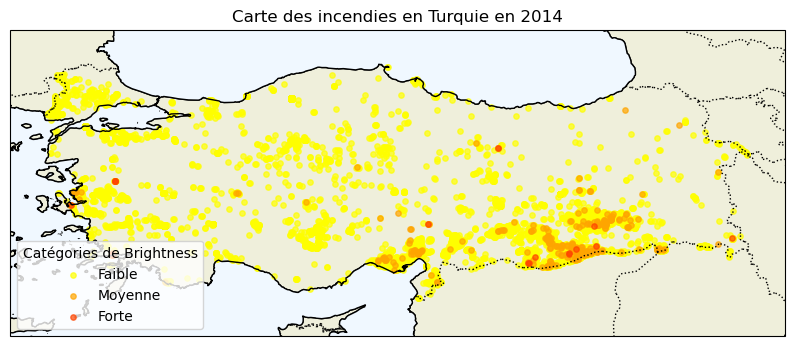

Année 2015: 18089 incendies détectés
Catégories présentes pour 2015: ['Faible', 'Moyenne', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


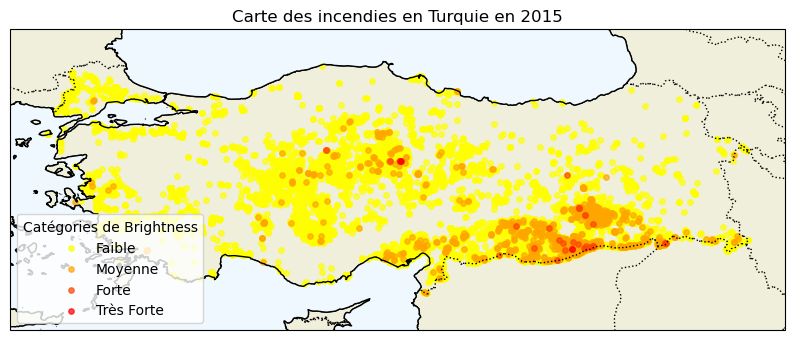

Année 2016: 13591 incendies détectés
Catégories présentes pour 2016: ['Moyenne', 'Faible', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


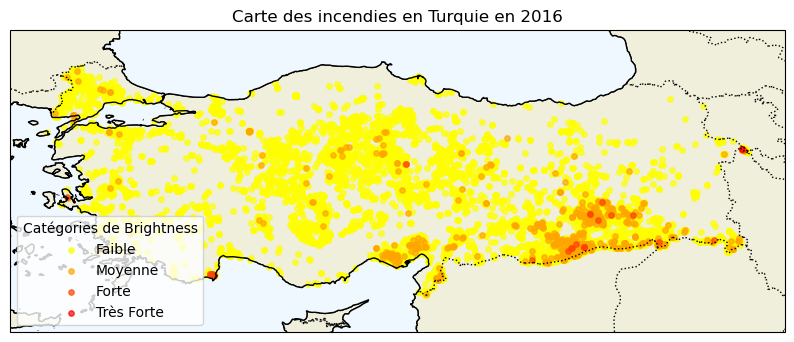

Année 2017: 9596 incendies détectés
Catégories présentes pour 2017: ['Faible', 'Moyenne', 'Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']
⚠️ Aucune donnée pour Très Forte en 2017


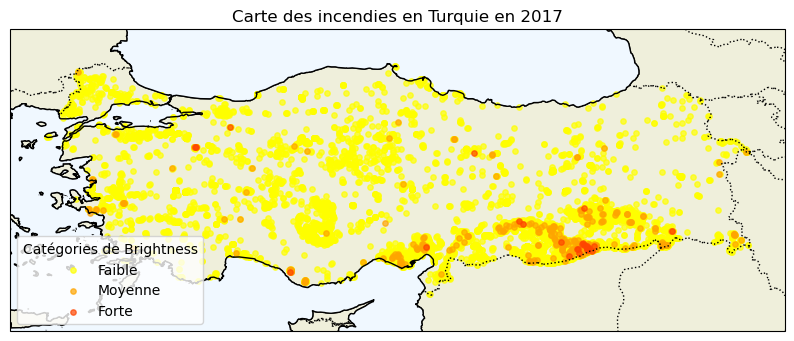

Année 2018: 8087 incendies détectés
Catégories présentes pour 2018: ['Faible', 'Moyenne', 'Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']
⚠️ Aucune donnée pour Très Forte en 2018


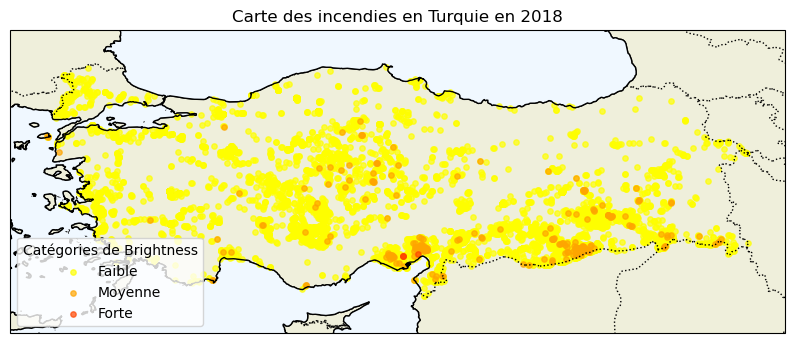

Année 2019: 8347 incendies détectés
Catégories présentes pour 2019: ['Faible', 'Moyenne', 'Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']
⚠️ Aucune donnée pour Très Forte en 2019


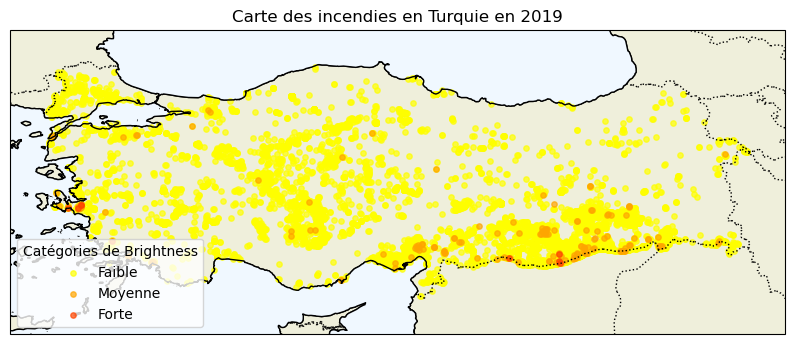

Année 2020: 8834 incendies détectés
Catégories présentes pour 2020: ['Faible', 'Moyenne', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


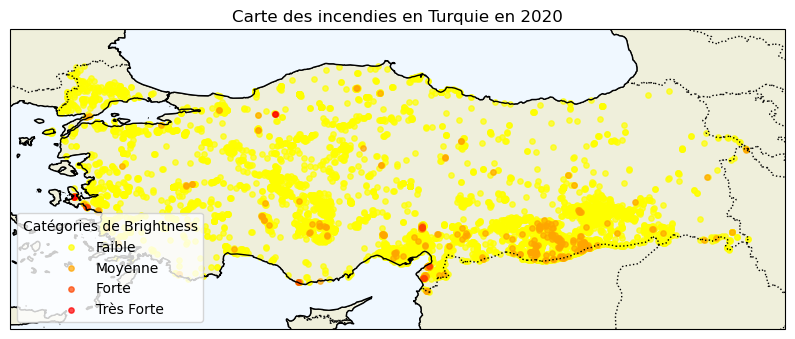

Année 2021: 6312 incendies détectés
Catégories présentes pour 2021: ['Faible', 'Moyenne', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


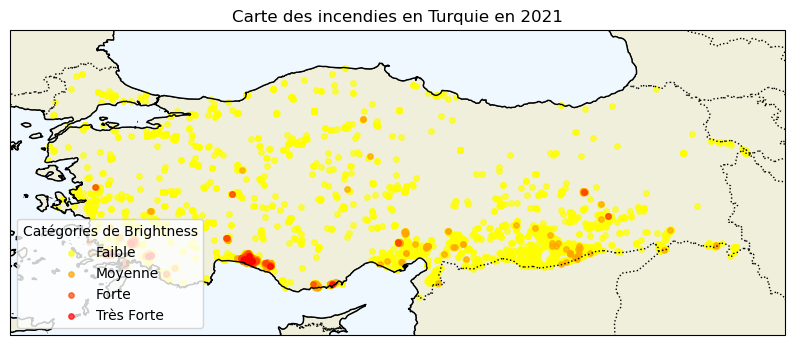

In [43]:
# Conversion des années en entiers
df['year'] = df['year'].astype(int)

# Mapping des catégories pour qu'elles correspondent
category_mapping = {
    "Zone 1": "Faible",
    "Zone 2": "Moyenne",
    "Zone 3": "Forte",
    "Zone 4": "Très Forte"
}
df['brightness_category'] = df['brightness_category'].map(category_mapping)

years = df['year'].unique()
colors = ["yellow", "orange", "orangered", "red"]
categories = ["Faible", "Moyenne", "Forte", "Très Forte"]

images = []  # Stocker les chemins des images générées

for year in years:
    df_year = df[df['year'] == year]
    
    print(f"Année {year}: {len(df_year)} incendies détectés")
    if df_year.empty:
        print(f"⚠️ Pas d'incendies pour {year}, on passe à l'année suivante.")
        continue

    print(f"Catégories présentes pour {year}:", df_year['brightness_category'].unique())
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    # Ajustement de la zone en fonction des incendies présents
    if not df_year.empty:
        ax.set_extent([df_year['longitude'].min() - 1, df_year['longitude'].max() + 1,
                       df_year['latitude'].min() - 1, df_year['latitude'].max() + 1], 
                       crs=ccrs.PlateCarree())

    # Ajouter les éléments de la carte
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor="black")
    ax.add_feature(cfeature.OCEAN, facecolor="aliceblue")

    # Ajouter les feux sur la carte
    for category, color in zip(categories, colors):
        category_data = df_year[df_year['brightness_category'] == category]
        if category_data.empty:
            print(f"⚠️ Aucune donnée pour {category} en {year}")
            continue
        ax.scatter(category_data['longitude'], category_data['latitude'],
                   transform=ccrs.PlateCarree(), s=15, alpha=0.7, color=color, label=category)

    plt.legend(title="Catégories de Brightness", loc="lower left")
    plt.title(f'Carte des incendies en Turquie en {year}')
    
    plt.show()

C:\Users\laure\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


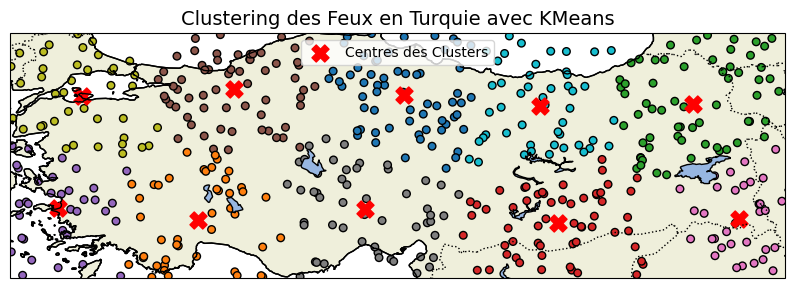

In [44]:
# Charger le dataset (à remplacer par tes vraies données)
df = pd.DataFrame({
    'latitude': np.random.uniform(36.0, 42.0, 500),  # Latitudes en Turquie
    'longitude': np.random.uniform(26.0, 45.0, 500)  # Longitudes en Turquie
})

# Définition des limites géographiques de la Turquie
lon_min, lon_max = 26.0, 45.0
lat_min, lat_max = 36.0, 42.0

# Définir le nombre de clusters (à ajuster selon les données)
n_clusters = 10

# Appliquer le clustering KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df[['longitude', 'latitude']])

# Récupérer les centres des clusters
cluster_centers = kmeans.cluster_centers_

# Créer la figure et l'axe avec Cartopy
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Ajouter les éléments de base de la carte
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAKES, edgecolor='black')

# Définir les limites de la carte
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# Afficher les points de feu colorés par cluster
scatter = ax.scatter(df['longitude'], df['latitude'], c=df['cluster'], cmap='tab10', edgecolors='black', s=30, transform=ccrs.PlateCarree())

# Afficher les centres des clusters
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1], c='red', marker='X', s=150, label='Centres des Clusters', transform=ccrs.PlateCarree())

# Ajouter la légende
ax.legend()

# Ajouter un titre
ax.set_title('Clustering des Feux en Turquie avec KMeans', fontsize=14)

# Afficher la carte
plt.show()

In [45]:
# Charger le dataset (à remplacer par ton vrai dataset)
df = pd.DataFrame({
    'latitude': np.random.uniform(36.0, 42.0, 500),  # Génération aléatoire de latitudes en Turquie
    'longitude': np.random.uniform(26.0, 45.0, 500),  # Génération aléatoire de longitudes en Turquie
    'annee': np.random.randint(2000, 2022, 500)  # Années entre 2000 et 2021
})

In [46]:
# Définition des limites de la Turquie
lon_min, lon_max = 26.0, 45.0
lat_min, lat_max = 36.0, 42.0

📅 Création de la carte pour l'année 2000...


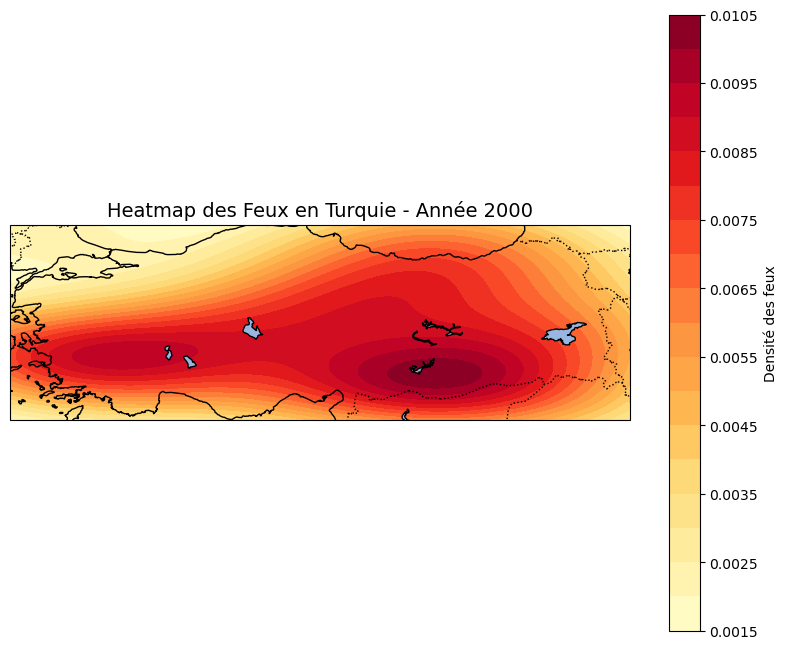

📅 Création de la carte pour l'année 2001...


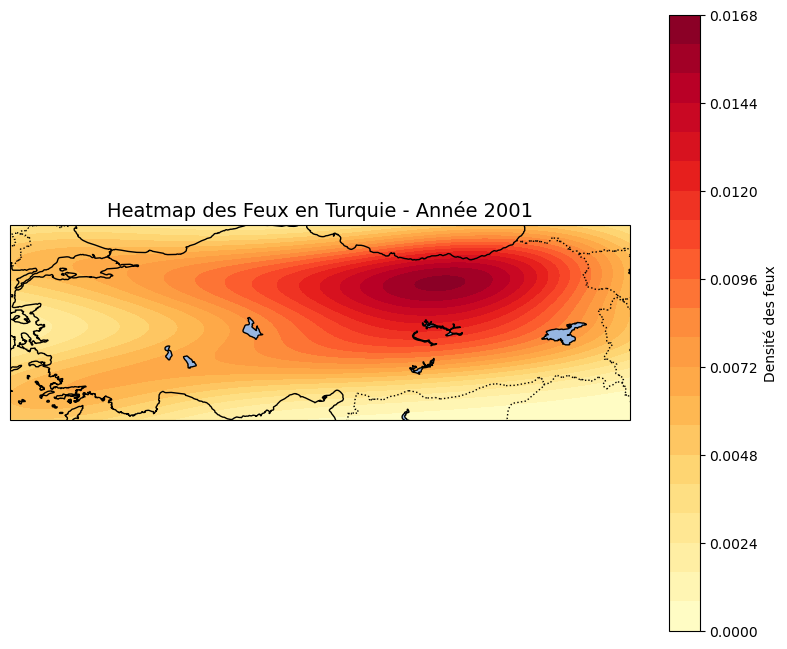

📅 Création de la carte pour l'année 2002...


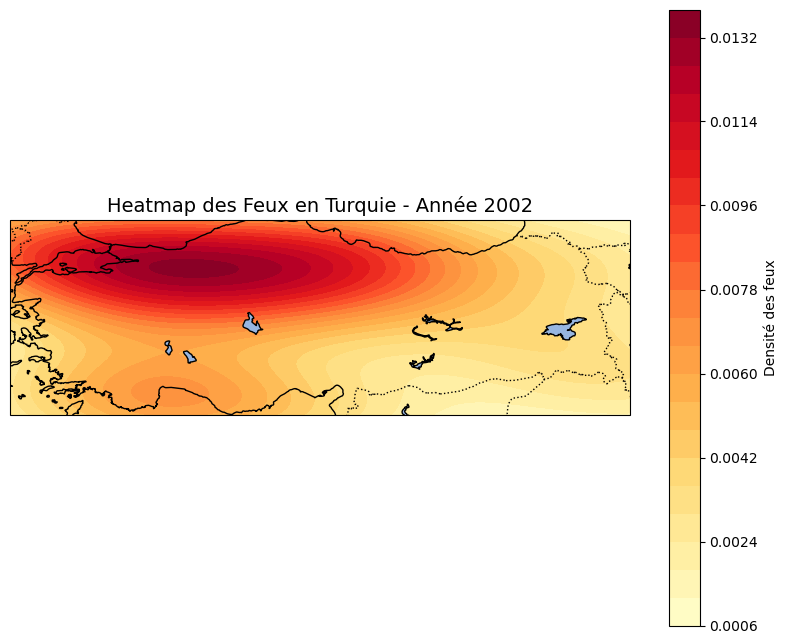

📅 Création de la carte pour l'année 2003...


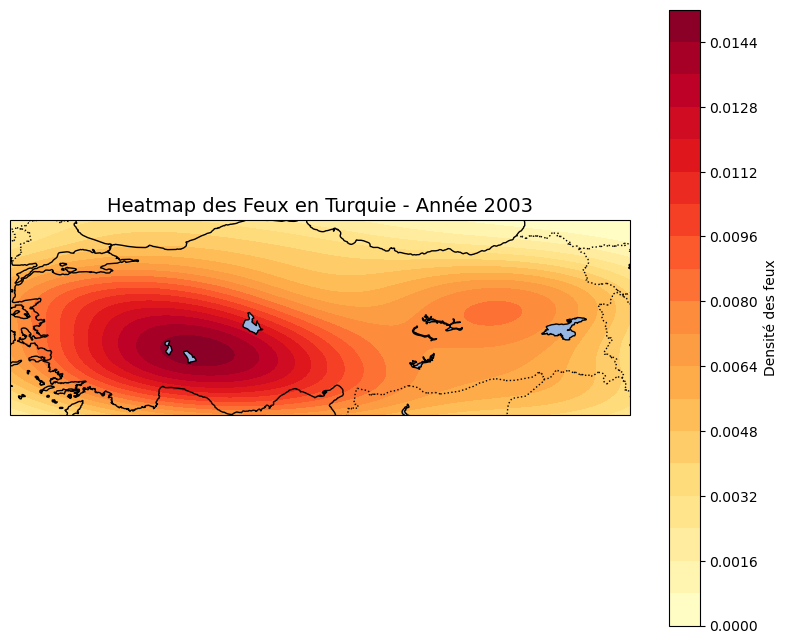

📅 Création de la carte pour l'année 2004...


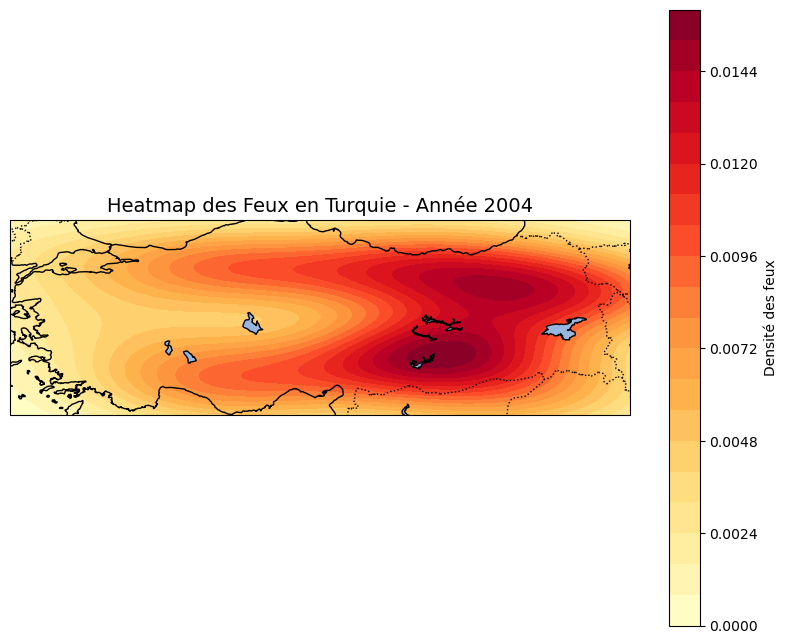

📅 Création de la carte pour l'année 2005...


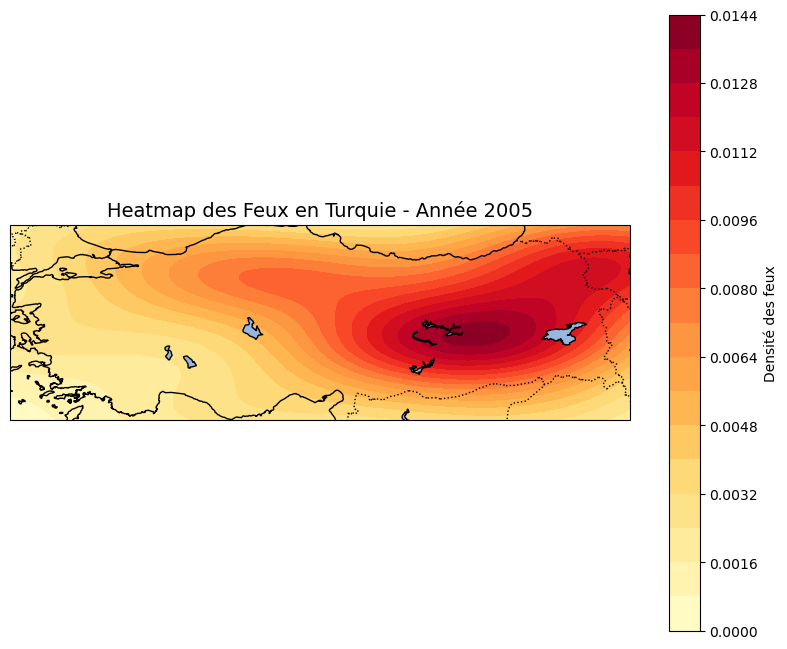

📅 Création de la carte pour l'année 2006...


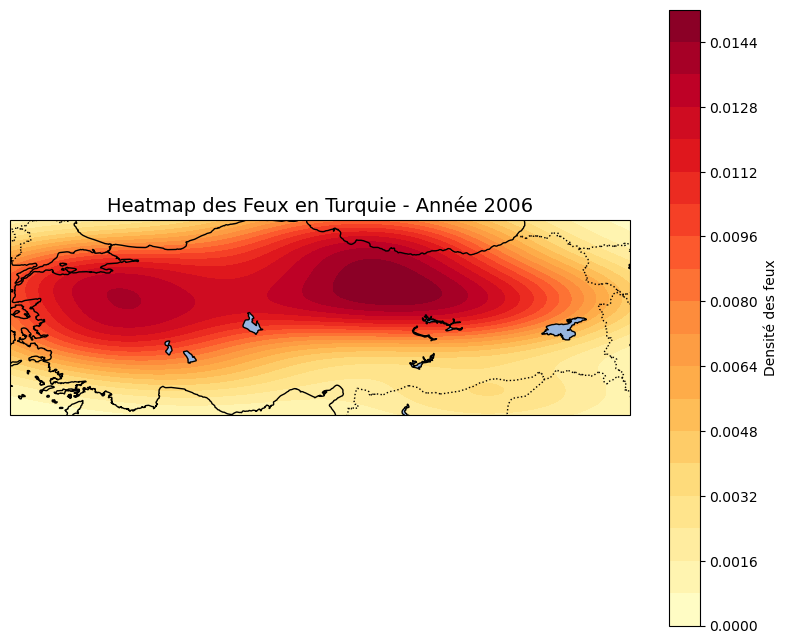

📅 Création de la carte pour l'année 2007...


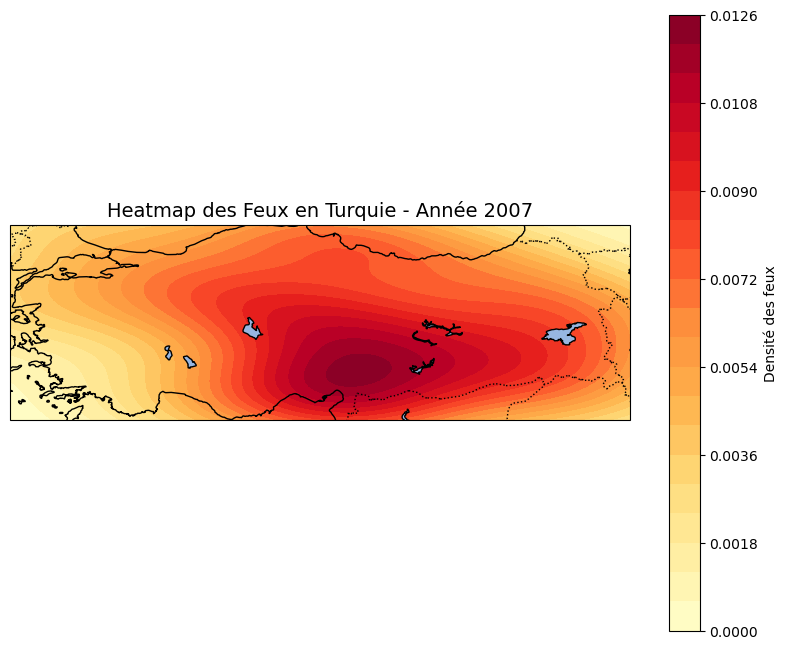

📅 Création de la carte pour l'année 2008...


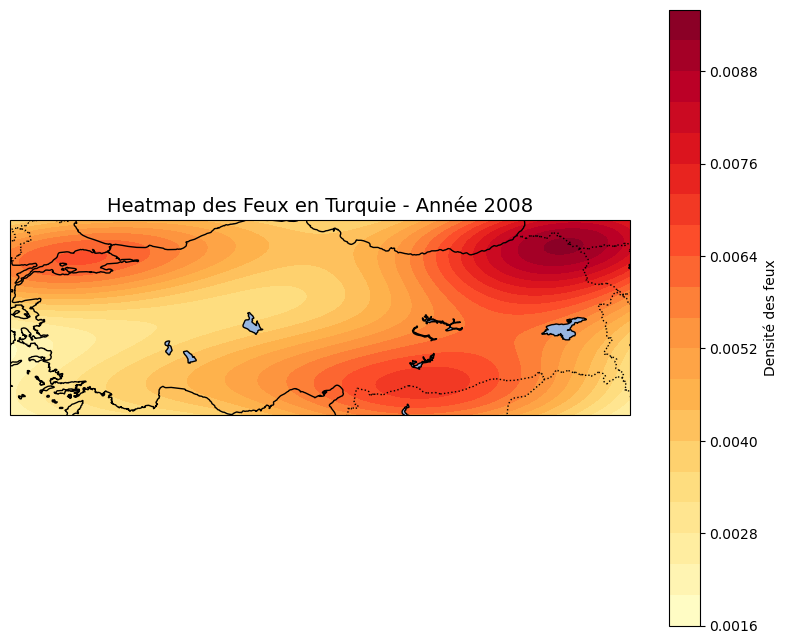

📅 Création de la carte pour l'année 2009...


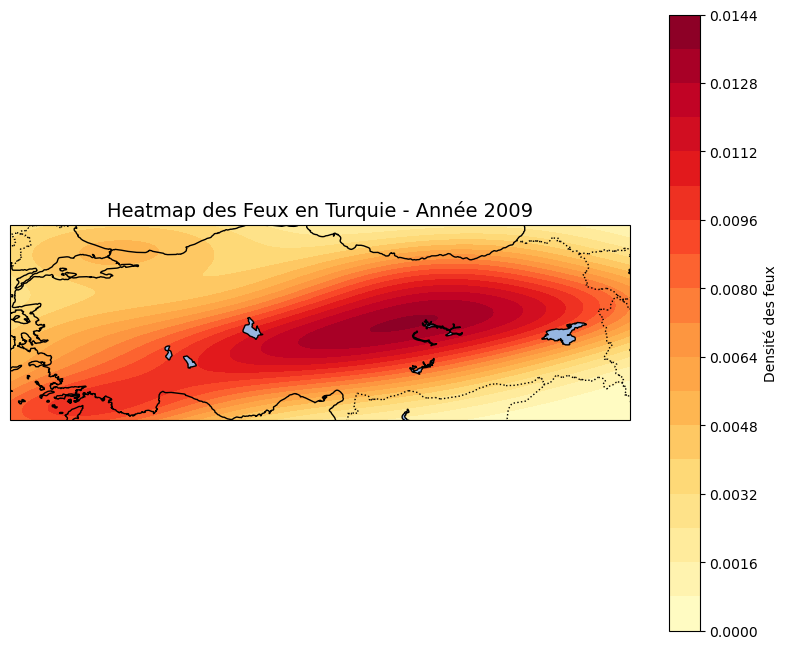

📅 Création de la carte pour l'année 2010...


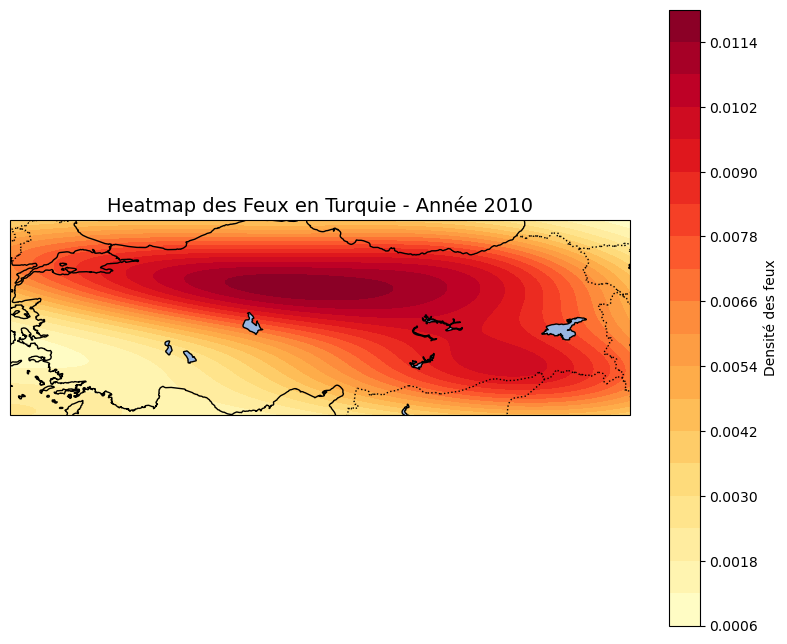

📅 Création de la carte pour l'année 2011...


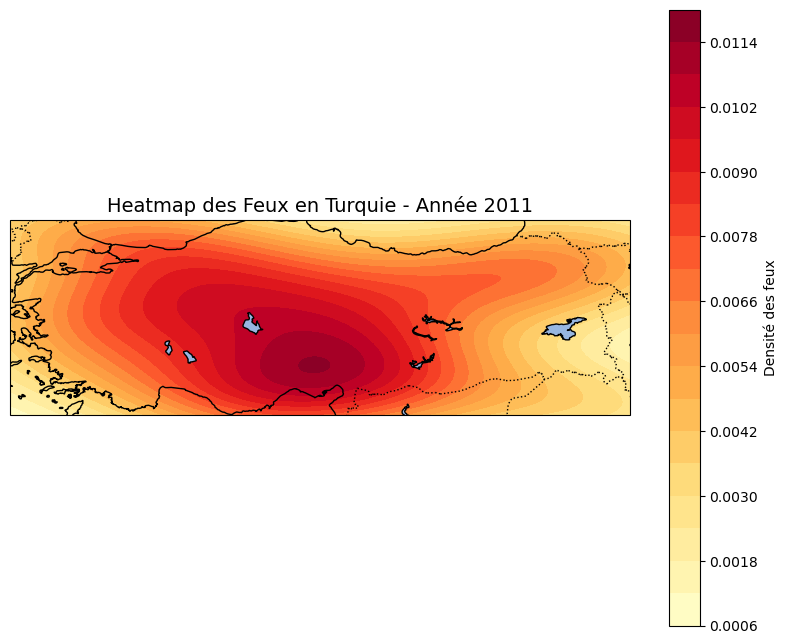

📅 Création de la carte pour l'année 2012...


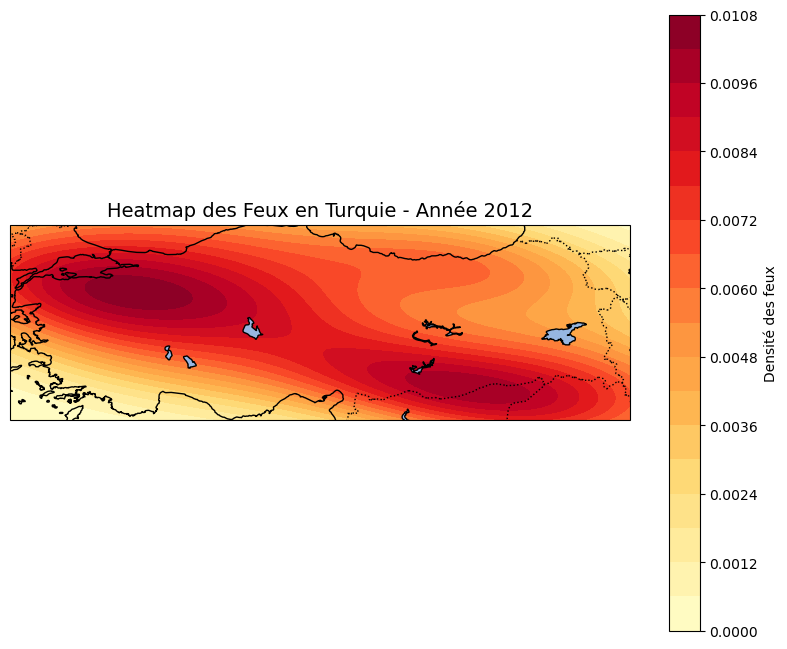

📅 Création de la carte pour l'année 2013...


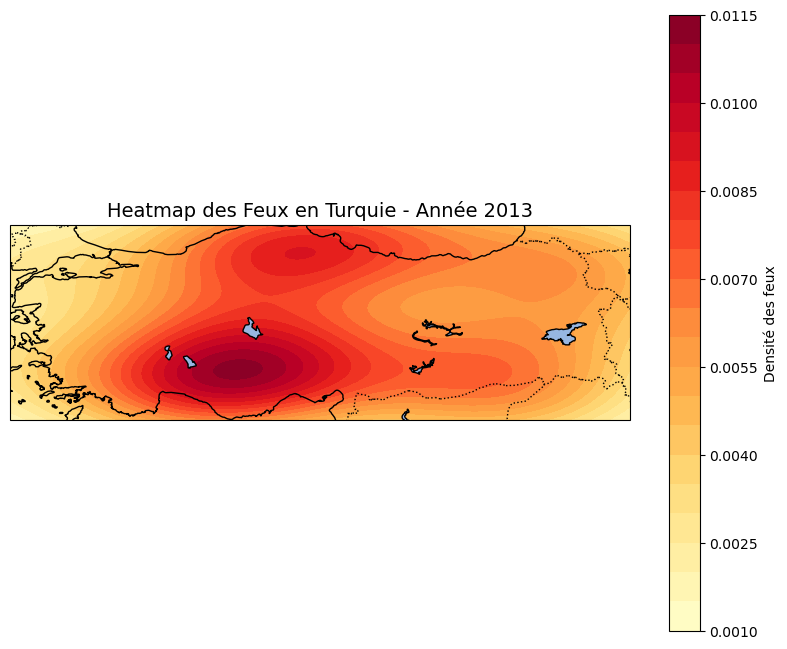

📅 Création de la carte pour l'année 2014...


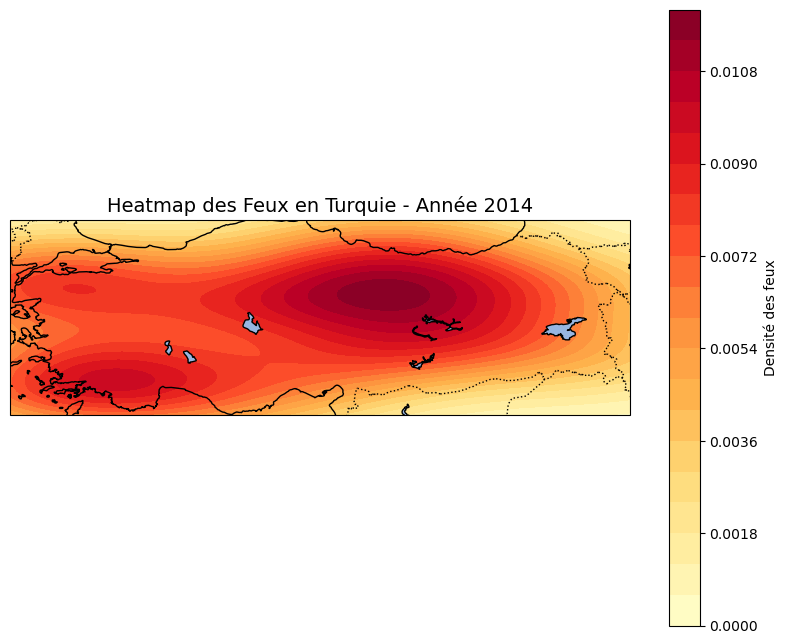

📅 Création de la carte pour l'année 2015...


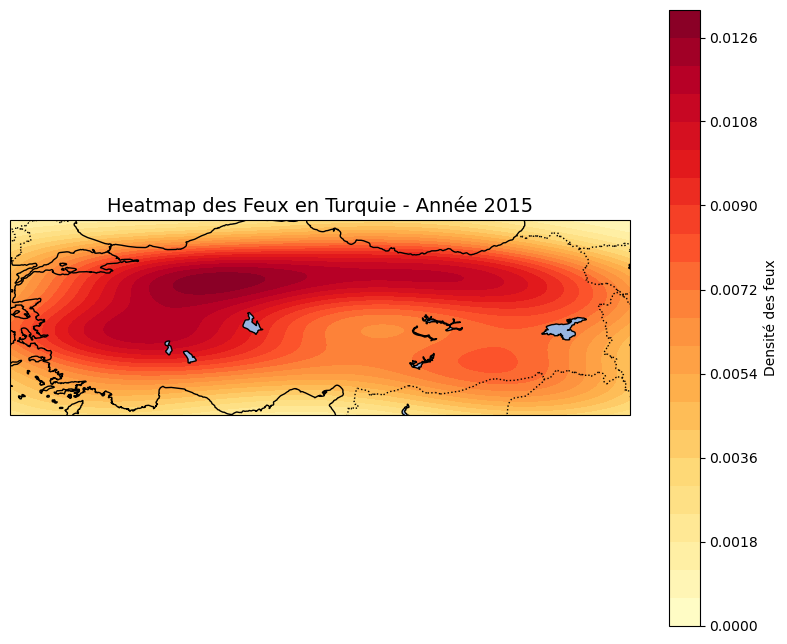

📅 Création de la carte pour l'année 2016...


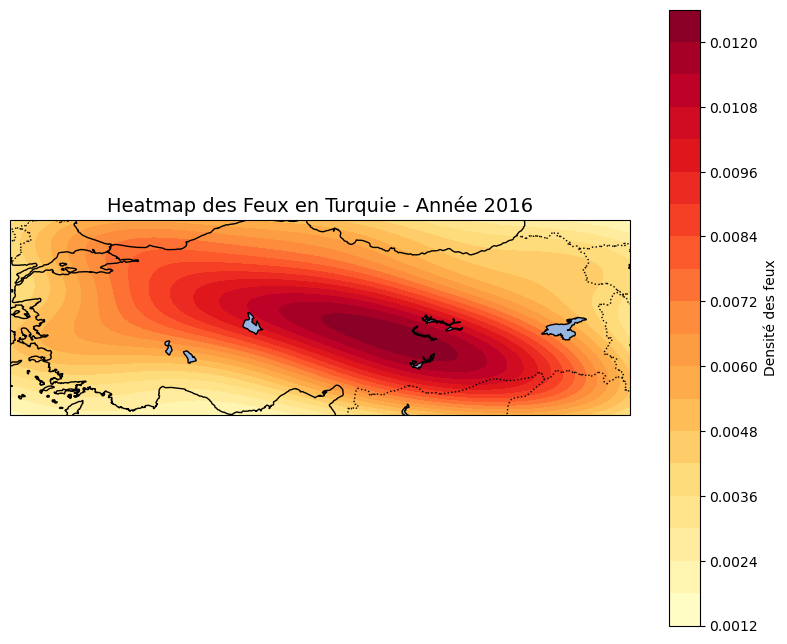

📅 Création de la carte pour l'année 2017...


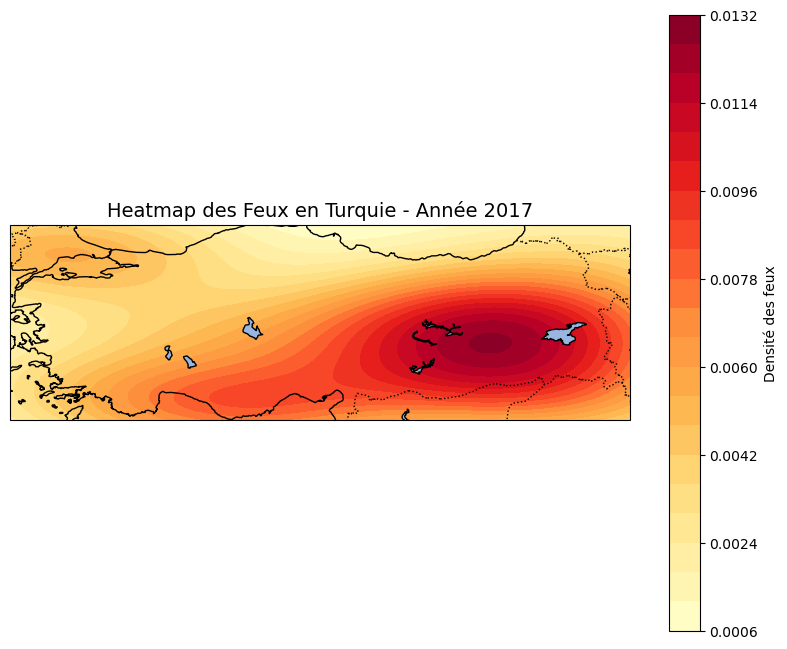

📅 Création de la carte pour l'année 2018...


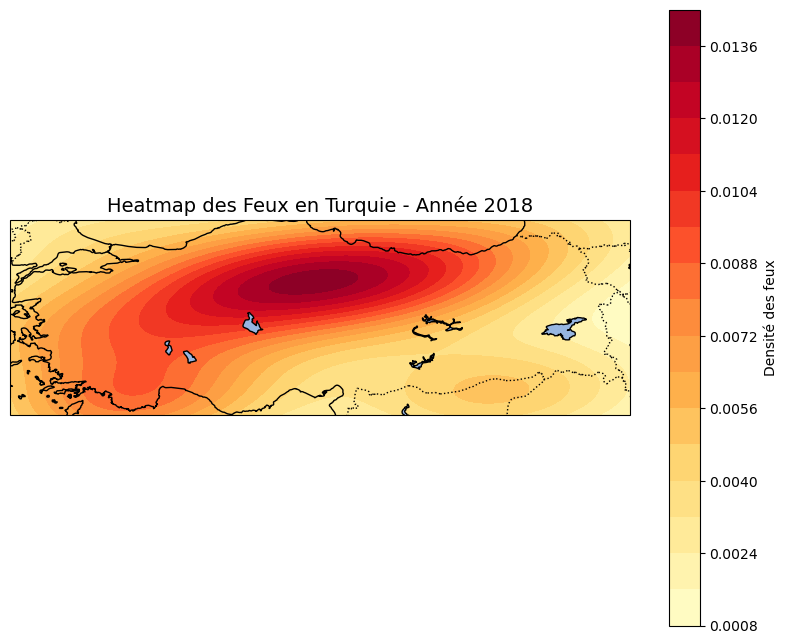

📅 Création de la carte pour l'année 2019...


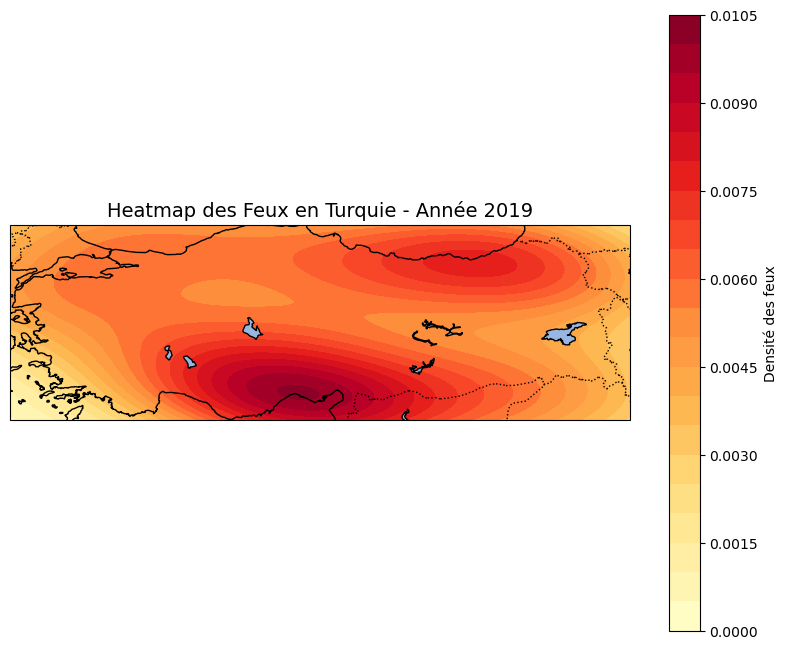

📅 Création de la carte pour l'année 2020...


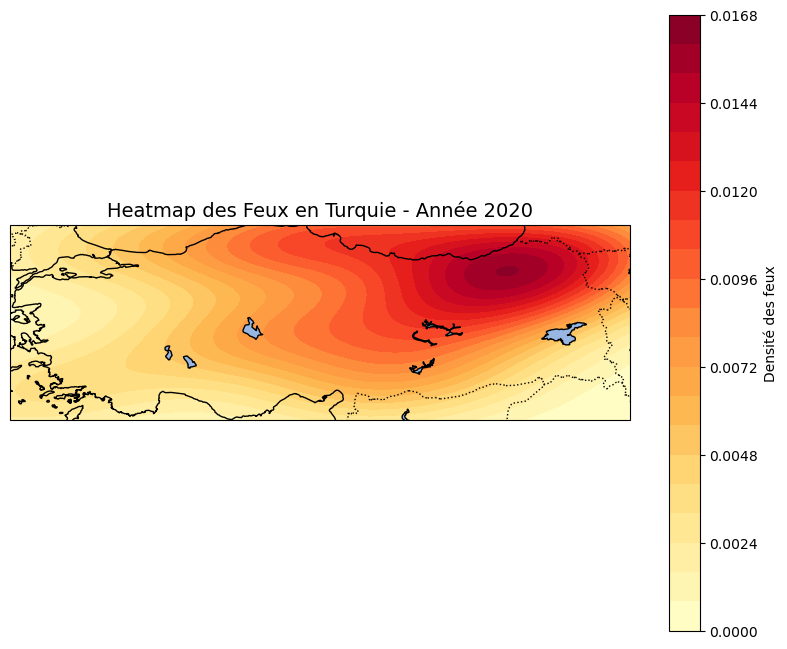

📅 Création de la carte pour l'année 2021...


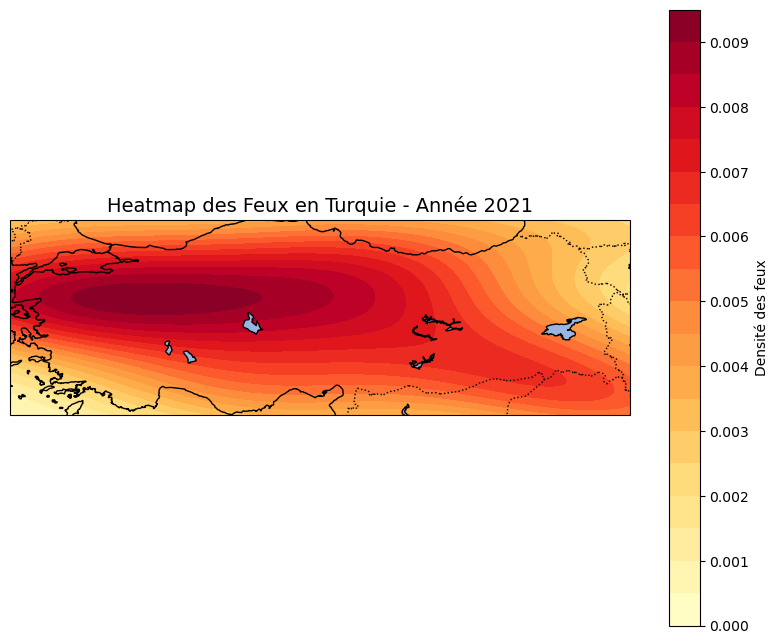

In [47]:
# Boucle de 2000 à 2021 pour générer les heatmaps
for annee in range(2000, 2022):
    print(f"📅 Création de la carte pour l'année {annee}...")

    # Filtrer les données pour l'année en cours
    df_annee = df[df['annee'] == annee]

    # Vérifier si on a des données pour cette année
    if df_annee.empty:
        print(f"⚠️ Aucune donnée pour {annee}, passage à l'année suivante.")
        continue

    # Créer la figure et l'axe avec Cartopy
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

    # Ajouter les éléments de base de la carte
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor='black')
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.LAKES, edgecolor='black')

    # Définir les limites de la carte
    ax.set_extent([lon_min, lon_max, lat_min, lat_max])

    # Vérifier s'il y a assez de points pour le KDE
    if len(df_annee) > 1:
        # Appliquer un KDE (estimation de densité de noyau)
        kde = gaussian_kde([df_annee['longitude'], df_annee['latitude']])

        # Créer une grille de points pour estimer la densité
        lon_grid, lat_grid = np.meshgrid(np.linspace(lon_min, lon_max, 500),
                                         np.linspace(lat_min, lat_max, 500))
        # Calculer la densité pour chaque point de la grille
        densities = kde([lon_grid.ravel(), lat_grid.ravel()]).reshape(lon_grid.shape)

        # Afficher la heatmap sur la carte
        cf = ax.contourf(lon_grid, lat_grid, densities, 20, cmap='YlOrRd', transform=ccrs.PlateCarree())

        # Ajouter une barre de couleur
        cbar = fig.colorbar(cf, ax=ax, orientation='vertical', label='Densité des feux')

    else:
        # Si un seul point, afficher uniquement les feux avec scatter plot
        ax.scatter(df_annee['longitude'], df_annee['latitude'], c='red', s=50, transform=ccrs.PlateCarree(), label='Feux')

    # Ajouter un titre
    ax.set_title(f'Heatmap des Feux en Turquie - Année {annee}', fontsize=14)

    # Ajouter la légende si nécessaire
    if len(df_annee) == 1:
        ax.legend()

    # Afficher la carte
    plt.show()